In [1]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torchinfo import summary #To display model architecture
from torchvision import datasets, transforms #Provide access to common datasets and data preprocessing (normalization, augmentation)
import matplotlib.pyplot as plt
import numpy as np
import random
import time

%matplotlib inline

In [2]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

    

#### Prepare Data loader

In [7]:
#Step 1: Download the training set without normalization
raw_transform = transforms.Compose([transforms.ToTensor()])

train_set_raw = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=True, transform=raw_transform)

#Step 2: Compute mean and std from the training set
all_pixels = torch.cat([img.view(-1) for img, _ in train_set_raw])

mean = all_pixels.mean().item()
std = all_pixels.std().item()

print(f"Computed mean: {mean}, Computed std: {std}")

#Step 3: Define new transform using the computed mean and std
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]
)

#Step 4: Reload datasets with proper normalization
train_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=True, transform=transform)
val_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=False, transform=transform)

print(f"Total train images: {len(train_set)}")
print(f"Total val images: {len(val_set)}")

Computed mean: 0.28604063391685486, Computed std: 0.3530242443084717
Total train images: 60000
Total val images: 10000


In [8]:
#Defining data loader for training and validation dataset
train_loader = torch.utils.data.DataLoader(train_set, shuffle=True, batch_size=64)
val_loader = torch.utils.data.DataLoader(val_set, shuffle=False, batch_size=64)

In [9]:
#Class to idx mapping
class_mapping = {
    0:"T-shirt",
    1:"Trouser",
    2:"Pullover",
    3:"Dress",
    4:"Coat",
    5:"Sandal",
    6:"Shirt",
    7:"Sneaker",
    8:"Bag",
    9:"Ankle boot"
}

#### 2. Dataset Visualization

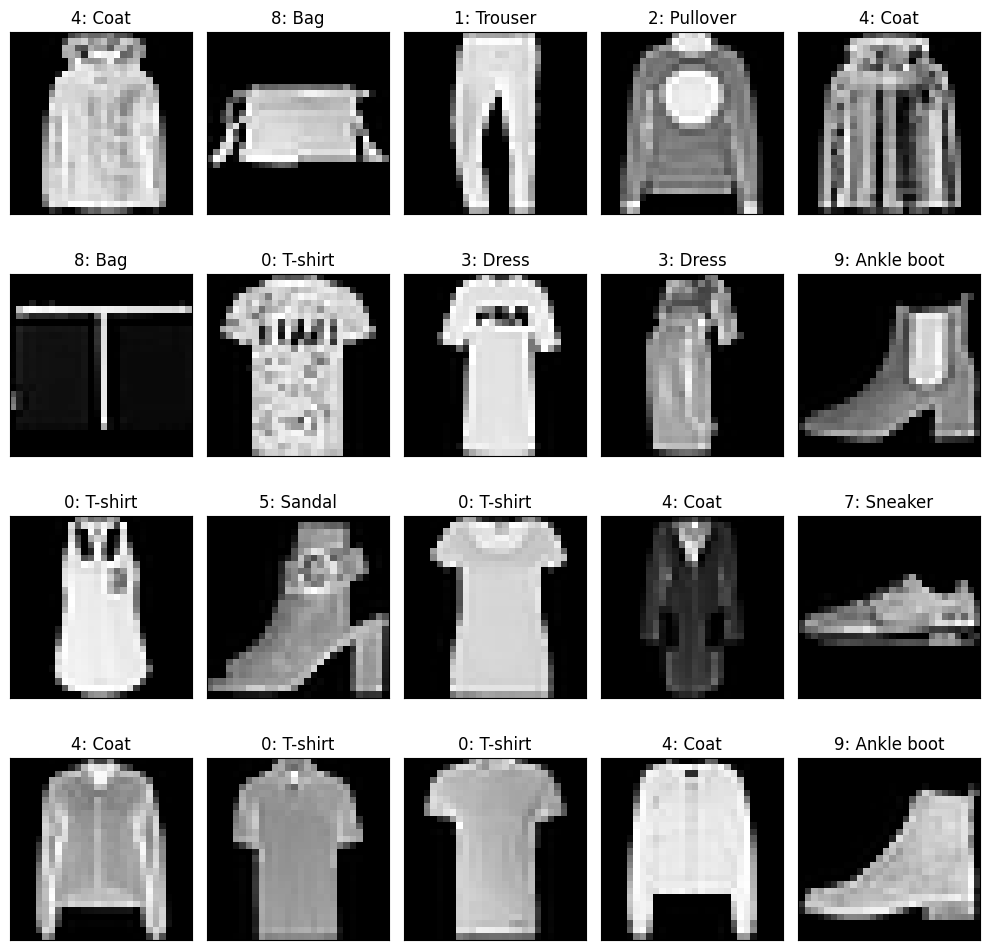

In [13]:
def visualize_images(trainloader, number_of_images=20):
    fig = plt.figure(figsize=(10,10))

    images, labels = next(iter(train_loader))

    num_rows = 4
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        ax.imshow(np.squeeze(image), cmap='gray')

        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")

    fig.tight_layout()

    plt.show()
visualize_images(train_loader)

#### 3. Model Architecture (MLP)

In [14]:
class MLP(nn.Module):
    """
    A Multi-Layer Perceptron (MLP) model for classification tasks.

    This MLP consists of five fully connected layers with batch normalization,
    Relu activations, and dropout for regularization.
    """

    def __init__(self, num_classes):
        super().__init__()

        #Fully Connected layers with decressing number of neurons
        self.fc0 = nn.Linear(784, 512)
        self.bn0 = nn.BatchNorm1d(512)

        self.fc1 = nn.Linear(512, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.view(x.shape[0], -1) #Reshaping for compatibility with fully connected layers

        x = F.relu(self.bn0(self.fc0(x)))
        x = self.dropout(x)

        x = F.relu(self.bn1(self.fc1(x)))

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.fc3(x)))

        x = F.log_softmax(self.fc4(x), dim=1) # Log probability for each class

        return x

#instantiate MLP
mlp_model = MLP(num_classes=10)

In [16]:
print(summary(mlp_model, input_size=(1,1,28,28), row_settings=["var_names"]))

Layer (type (var_name))                  Output Shape              Param #
MLP (MLP)                                [1, 10]                   --
├─Linear (fc0)                           [1, 512]                  401,920
├─BatchNorm1d (bn0)                      [1, 512]                  1,024
├─Dropout (dropout)                      [1, 512]                  --
├─Linear (fc1)                           [1, 256]                  131,328
├─BatchNorm1d (bn1)                      [1, 256]                  512
├─Linear (fc2)                           [1, 128]                  32,896
├─BatchNorm1d (bn2)                      [1, 128]                  256
├─Dropout (dropout)                      [1, 128]                  --
├─Linear (fc3)                           [1, 64]                   8,256
├─BatchNorm1d (bn3)                      [1, 64]                   128
├─Linear (fc4)                           [1, 10]                   650
Total params: 576,970
Trainable params: 576,970
Non-trainable

#### Training Configuration

In [17]:
criterion = F.nll_loss #Negative log likelihood

optimizer = optim.Adam(mlp_model.parameters(), lr=1e-2)

num_epochs = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#### Model Training

In [31]:
def train(model, trainloader, criterion, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(trainloader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy
        

In [38]:
def validation(model, val_loader, criterion, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [43]:
def main(model, trainloader, val_loader, epochs =5, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = train(mlp_model,train_loader, criterion, optimizer, DEVICE)
        val_loss, val_accuracy = validation(mlp_model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

    plt.figure(figsize=[12,5])

    plt.subplot(1,2,1)
    plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
    plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")

    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
    plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")

    plt.legend()

    

Epoch 1 - Train loss: 0.3034032980786331 Train accuracy: 88.84333333333333 %%% Val loss: 0.31290971838934406 Val accuracy: 88.57
Epoch 2 - Train loss: 0.29251583738685416 Train accuracy: 89.24 %%% Val loss: 0.30921433500613377 Val accuracy: 88.96
Epoch 3 - Train loss: 0.28385774029502225 Train accuracy: 89.66833333333334 %%% Val loss: 0.30999053051327446 Val accuracy: 88.63
Epoch 4 - Train loss: 0.2775228273139389 Train accuracy: 89.775 %%% Val loss: 0.31391653902591415 Val accuracy: 88.62
Epoch 5 - Train loss: 0.2696711173586881 Train accuracy: 90.07166666666667 %%% Val loss: 0.2995339772978406 Val accuracy: 89.11


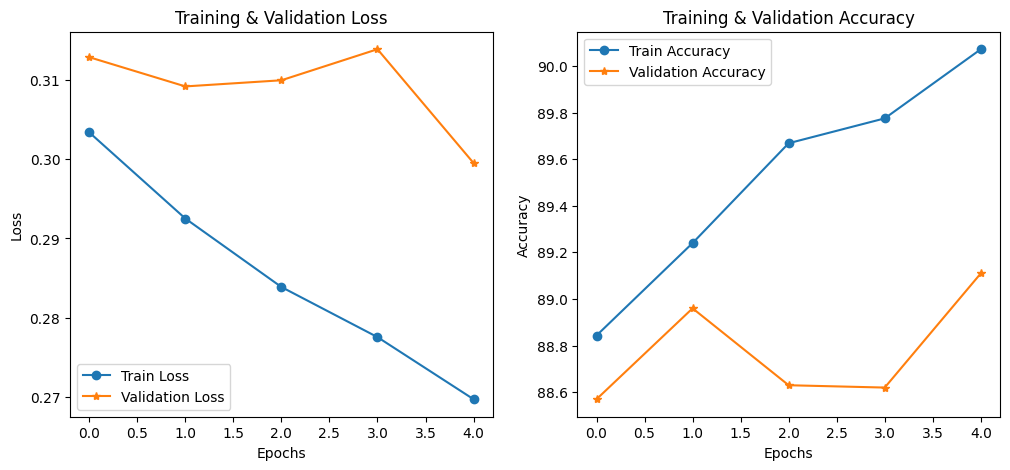

In [44]:
main(mlp_model, train_loader, val_loader, 5, 'cpu')

#### Inference Result

(-0.5, 27.5, 27.5, -0.5)

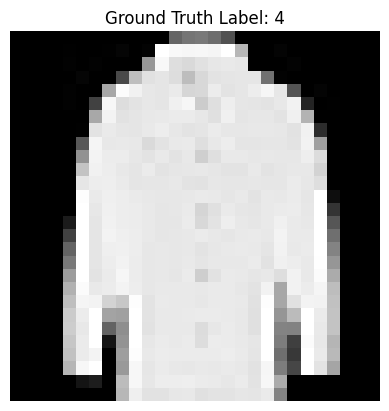

In [46]:
images, gt_labels = next(iter(val_loader))

rand_idx = random.choice(range(len(images)))

plt.imshow(images[rand_idx].squeeze(), cmap='gray')

plt.title(f"Ground Truth Label: {gt_labels[rand_idx]}")

plt.axis("off")

In [47]:
mlp_model.eval() #disable dropout and change batch norm behaviour

with torch.no_grad():
    output = mlp_model(images[rand_idx])

In [52]:
class_mapping[output.softmax(dim=1).argmax().item()]

'Coat'

In [55]:
images[rand_idx].size()

torch.Size([1, 28, 28])